# **Assignment: Sentiment Analysis using NLP Pipeline & ML Models**

In [8]:
# Import required libraries
import pandas as pd
import re
import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [21]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.6 MB/s eta 0:00:00


# 🔹  Data Understanding

In [2]:
# Load dataset
df = pd.read_csv('IMDB Dataset.csv')
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [4]:
print(df.shape)
print(df.columns)

(50000, 2)
Index(['review', 'sentiment'], dtype='object')


In [6]:
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

print("\nSample Reviews:\n")
print(df['review'].sample(5))


Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Reviews:

3372     People who actually liked Problem Child (1990)...
38746    Six teenagers go to an old remote abandoned sc...
5292     This movie was absolute trash. The director an...
41753    Karen goes into a Japanese house as a substitu...
34645    I want to say that I went to this movie with m...
Name: review, dtype: object


# 🔹  NLP Preprocessing

In [9]:
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [13]:
#lowercase
def to_lowercase(text):
    return text.lower()

#remove URL's
def remove_urls_html(text):
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'<.*?>', '', text)           # remove HTML tags
    return text

#removes punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

#remove numbers and extra's
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

#tokenization
def tokenize_text(text):
    return text.split()

#remove stopwords
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

#stemming
def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

#lemmatization
def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [14]:
def preprocess_text(text, use_stemming=False):
    text = to_lowercase(text)
    text = remove_urls_html(text)
    text = remove_punctuation(text)
    text = remove_numbers(text)
    tokens = tokenize_text(text)
    tokens = remove_stopwords(tokens)

    if use_stemming:
        tokens = apply_stemming(tokens)
    else:
        tokens = apply_lemmatization(tokens)

    # Join back to sentence
    return " ".join(tokens)

In [15]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

# View results
print(df[['review', 'cleaned_review']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one reviewer mentioned watching oz episode you...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  


In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

# Check
print(df[['sentiment', 'sentiment_encoded']].head())

  sentiment  sentiment_encoded
0  positive                  1
1  positive                  1
2  positive                  1
3  negative                  0
4  positive                  1


# 🔹  Feature Engineering

In [19]:
X = df['cleaned_review']
y = df['sentiment_encoded']
from sklearn.feature_extraction.text import CountVectorizer

#Initialize Bag of Words
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(X)

print("BoW Shape:", X_bow.shape)

BoW Shape: (50000, 5000)


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (50000, 5000)


In [23]:
# Word2vector
from gensim.models import Word2Vec
import numpy as np

# Tokenize reviews (split words)
tokenized_reviews = [text.split() for text in X]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

def get_avg_word2vec(tokens, model, vector_size):
    vec = np.zeros(vector_size)
    count = 0

    for word in tokens:
        if word in model.wv:
            vec += model.wv[word]
            count += 1

    if count != 0:
        vec = vec / count

    return vec

In [24]:
X_w2v = np.array([
    get_avg_word2vec(text.split(), w2v_model, 100)
    for text in X
])

print("Word2Vec Shape:", X_w2v.shape)

Word2Vec Shape: (50000, 100)


Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# 🔹  Model Building

In [33]:
# 1. Logistic Regression

from sklearn.linear_model import LogisticRegression

# Initialize model
lr = LogisticRegression(max_iter=1000)

# Train
lr.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = lr.predict(X_test_tfidf)

In [34]:
# 2.Naive Bayes

from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

In [35]:
# 3. Decision tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_tfidf, y_train)
y_pred_dt = dt.predict(X_test_tfidf)

In [36]:
# 4. Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

In [37]:
# 5. XGBoost

!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_tfidf, y_train)
y_pred_xgb = xgb.predict(X_test_tfidf)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:12:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [38]:
results = {
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

# 🔹  Model Evaluation

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [41]:
def evaluate_model(y_test, y_pred, model_name):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n📊 {model_name} Performance:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return accuracy, precision, recall, f1

In [42]:
results = {}

results['Logistic Regression'] = evaluate_model(y_test, y_pred_lr, "Logistic Regression")
results['Naive Bayes'] = evaluate_model(y_test, y_pred_nb, "Naive Bayes")
results['Decision Tree'] = evaluate_model(y_test, y_pred_dt, "Decision Tree")
results['Random Forest'] = evaluate_model(y_test, y_pred_rf, "Random Forest")
results['XGBoost'] = evaluate_model(y_test, y_pred_xgb, "XGBoost")



📊 Logistic Regression Performance:
Accuracy : 0.8846
Precision: 0.8758
Recall   : 0.8984
F1 Score : 0.8870

📊 Naive Bayes Performance:
Accuracy : 0.8491
Precision: 0.8476
Recall   : 0.8541
F1 Score : 0.8508

📊 Decision Tree Performance:
Accuracy : 0.7092
Precision: 0.7157
Recall   : 0.7015
F1 Score : 0.7086

📊 Random Forest Performance:
Accuracy : 0.8500
Precision: 0.8594
Recall   : 0.8397
F1 Score : 0.8494

📊 XGBoost Performance:
Accuracy : 0.8593
Precision: 0.8447
Recall   : 0.8831
F1 Score : 0.8635


In [45]:
# Model comparision Table
results_df = pd.DataFrame(results,
                          index=['Accuracy', 'Precision', 'Recall', 'F1 Score']).T

print("\n📊 Model Comparison Table:")
print(results_df)

best_model = results_df['Accuracy'].idxmax()
print(f"\n Best Model based on Accuracy: {best_model}")


📊 Model Comparison Table:
                     Accuracy  Precision    Recall  F1 Score
Logistic Regression    0.8846   0.875798  0.898393  0.886951
Naive Bayes            0.8491   0.847578  0.854138  0.850845
Decision Tree          0.7092   0.715732  0.701528  0.708559
Random Forest          0.8500   0.859435  0.839651  0.849428
XGBoost                0.8593   0.844723  0.883112  0.863491

 Best Model based on Accuracy: Logistic Regression


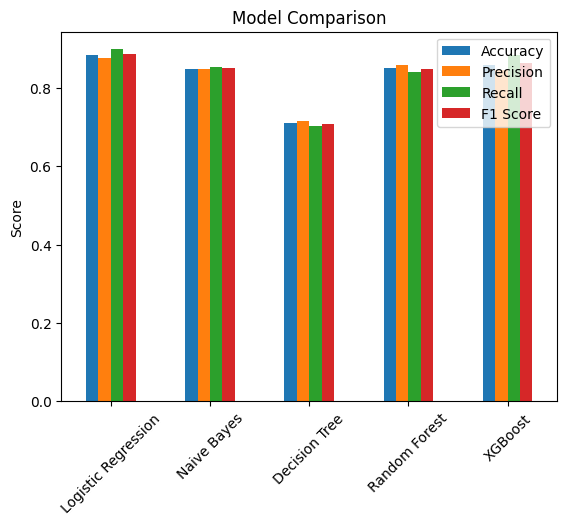

In [46]:
# Visualization
import matplotlib.pyplot as plt

results_df.plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

# 🔹  Comparison & Insights

## ✅ Preprocessing

Cleaning the text (removing HTML, punctuation, stopwords) and applying **lemmatization** helped improve the quality of data. It made the text more meaningful and easier for models to learn.

 **Best:** Cleaning + Lemmatization

---

## ✅ Vectorization

* **BoW** was simple but didn’t capture word importance.
* **TF-IDF** performed better as it gives more weight to important words.

 **Best:** TF-IDF

---

## ✅ Model Performance

* **Logistic Regression** gave the best and most consistent results.
* **Naive Bayes** was fast and performed well.
* **Decision Tree** performed poorly due to overfitting.

 **Best Model:** Logistic Regression

---

## ⚖️ Trade-offs

* Simpler methods (BoW, Naive Bayes) are fast but less accurate
* Advanced methods (TF-IDF, Logistic Regression) give better results
* Complex models (Random Forest, XGBoost) need more computation

---

## 🎯 Final Conclusion

The combination of **TF-IDF + Logistic Regression** worked best for this sentiment analysis task, giving the highest accuracy with efficient performance.
